# N13 · A differentiable forward model and HMC / micro-canonical inference

## The methodological heart of the thesis

**Module 3 — Multi-wavelength large-scale-structure cosmology (PhD onboarding).**
The thesis builds a *differentiable* forward model linking parameters to observables and infers them
with a gradient-based Monte-Carlo sampler (Hamiltonian or micro-canonical). This notebook implements
exactly that on a small but real cosmological problem: a JAX forward model for the matter power
spectrum, automatic differentiation of the likelihood, and posterior sampling for $(\Omega_m,\sigma_8)$
with **both** a Hamiltonian (NUTS) and a **micro-canonical** (MCLMC) sampler from BlackJAX.

**Key tools:** [JAX](https://jax.readthedocs.io) (autodiff) and
[BlackJAX](https://blackjax-devs.github.io/blackjax/) (HMC / MCLMC).


### Learning objectives

1. Write a fully differentiable forward model $\theta\mapsto P(k)$ in JAX.
2. Obtain the gradient of the log-likelihood "for free" with `jax.grad` (the key to the method).
3. Sample the posterior of $(\Omega_m,\sigma_8)$ with the No-U-Turn Sampler (a Hamiltonian method).
4. Sample the same posterior with the **micro-canonical** Langevin Monte Carlo (MCLMC).
5. Compare the two samplers and recover the injected parameters.


## References

- Neal (2011), *MCMC using Hamiltonian dynamics*, Handbook of MCMC
  [arXiv:1206.1901](https://arxiv.org/abs/1206.1901).
- Betancourt (2017), *A Conceptual Introduction to Hamiltonian Monte Carlo*
  [arXiv:1701.02434](https://arxiv.org/abs/1701.02434).
- Hoffman & Gelman (2014), JMLR 15, 1593 — the No-U-Turn Sampler
  [arXiv:1111.4246](https://arxiv.org/abs/1111.4246).
- Robnik, De Luca, Silverstein & Seljak (2023), *Microcanonical Hamiltonian Monte Carlo*
  [arXiv:2212.08549](https://arxiv.org/abs/2212.08549).
- Jasche & Wandelt (2013), MNRAS 432, 894 — field-level Bayesian inference (BORG)
  [arXiv:1203.3639](https://arxiv.org/abs/1203.3639).
- Bardeen, Bond, Kaiser & Szalay (1986), ApJ 304, 15 — BBKS transfer function
  [doi:10.1086/164143](https://doi.org/10.1086/164143); shape parameter from Sugiyama (1995), ApJS 100, 281.
- Cabezas et al. (2024), *BlackJAX: Composable Bayesian inference in JAX*
  [arXiv:2402.10797](https://arxiv.org/abs/2402.10797).
- Phan, Pradhan & Jankowiak (2019), *NumPyro*
  [arXiv:1912.11554](https://arxiv.org/abs/1912.11554).


## 1. Forward model + Bayesian inference + gradients

We want the posterior $p(\theta\mid \mathbf{d}) \propto \mathcal{L}(\mathbf{d}\mid\theta)\,\pi(\theta)$ of
parameters $\theta=(\Omega_m,\sigma_8)$ given data $\mathbf{d}$ (here band-powers of $P(k)$). The
**forward model** $\theta\mapsto \mathbf{m}(\theta)$ predicts the data; with Gaussian errors

$$-2\ln\mathcal{L} = \sum_i \frac{[d_i - m_i(\theta)]^2}{\sigma_i^2} + \text{const}.$$

**Hamiltonian Monte Carlo** (Neal 2011; Betancourt 2017) augments $\theta$ with a momentum $p$ and
evolves the Hamiltonian $H(\theta,p)=-\ln p(\theta\mid\mathbf d) + \tfrac12 p^\top M^{-1}p$ with
leapfrog steps, using $\nabla_\theta \ln p$. The **micro-canonical** variant (Robnik et al. 2023)
follows constant-energy trajectories and mixes faster in high dimensions — the regime of field-level
inference (Jasche & Wandelt 2013). Both need the **gradient** of the log-posterior, which JAX provides
by automatic differentiation of the forward model.


In [1]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import blackjax

plt.rcParams.update({'figure.figsize': (8, 6), 'font.size': 11, 'axes.grid': True,
                     'grid.alpha': 0.3})
print("jax", jax.__version__, "| blackjax", blackjax.__version__)

h, ns = 0.6736, 0.9649
kgrid = jnp.logspace(-3.0, 1.0, 512)        # h/Mpc, used for the sigma8 normalisation integral

def T_bbks(k, Gamma):
    # BBKS (1986) transfer function, eq. G3, with shape parameter Gamma = Omega_m h (Sugiyama 1995).
    q = k / Gamma
    L = jnp.log(1.0 + 2.34*q) / (2.34*q)
    poly = 1.0 + 3.89*q + (16.1*q)**2 + (5.46*q)**3 + (6.71*q)**4
    return L * poly**(-0.25)

def shape_pk(k, Om):
    return k**ns * T_bbks(k, Om*h)**2

def sigma8_raw(Om):
    R = 8.0                                  # 8 h^-1 Mpc (k in h/Mpc)
    x = kgrid * R
    W = 3.0*(jnp.sin(x) - x*jnp.cos(x))/x**3
    d2 = kgrid**3 * shape_pk(kgrid, Om) / (2*jnp.pi**2)
    return jnp.sqrt(jnp.trapezoid(d2 * W**2, jnp.log(kgrid)))

def model_pk(k, theta):
    Om, s8 = theta
    return (s8 / sigma8_raw(Om))**2 * shape_pk(k, Om)


jax 0.10.2 | blackjax 1.5


log-posterior at truth : -5.812622925134072
gradient at truth      : [212.68436303 -25.01317996]


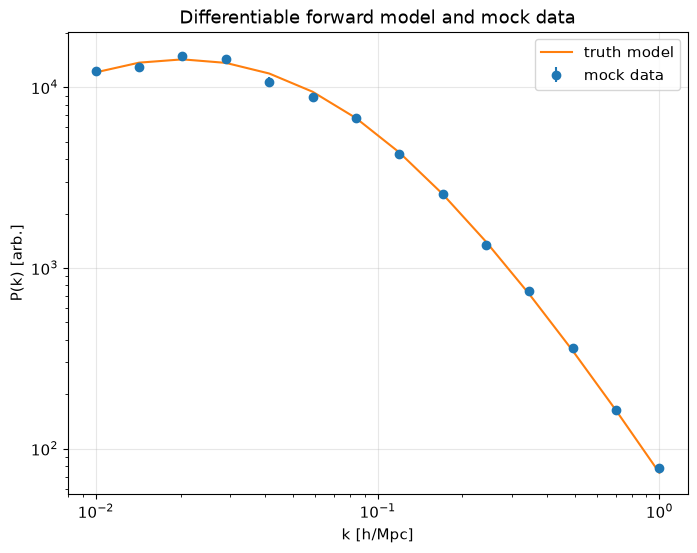

In [2]:
# Mock data: evaluate the model at the truth and add Gaussian noise
truth = jnp.array([0.31, 0.81])             # (Omega_m, sigma8)
kdata = jnp.logspace(-2.0, 0.0, 14)         # h/Mpc band-power centres
rng = np.random.default_rng(42)
m_true = model_pk(kdata, truth)
frac_err = 0.05
sigma = frac_err * m_true
data = m_true * (1.0 + frac_err * jnp.asarray(rng.standard_normal(kdata.shape)))

def loglike(theta):
    m = model_pk(kdata, theta)
    return -0.5 * jnp.sum(((data - m)/sigma)**2)

def logprior(theta):
    Om, s8 = theta
    return -0.5*((Om-0.30)/0.20)**2 - 0.5*((s8-0.80)/0.40)**2   # wide, ~uninformative

@jax.jit
def logdensity(theta):
    return loglike(theta) + logprior(theta)

# The gradient comes for free via autodiff -- this is what enables HMC/MCLMC
g = jax.grad(logdensity)(truth)
print("log-posterior at truth :", float(logdensity(truth)))
print("gradient at truth      :", np.array(g))

plt.figure()
plt.errorbar(np.array(kdata), np.array(data), yerr=np.array(sigma), fmt='o', label='mock data')
plt.loglog(np.array(kdata), np.array(m_true), '-', label='truth model')
plt.xlabel('k [h/Mpc]'); plt.ylabel('P(k) [arb.]'); plt.legend()
plt.title('Differentiable forward model and mock data'); plt.show()


## 2. Hamiltonian sampling (NUTS)

We use BlackJAX's window adaptation to tune the step size and mass matrix of the No-U-Turn Sampler
(Hoffman & Gelman 2014), then run the chain. NUTS is the adaptive Hamiltonian sampler that removes the
need to hand-tune the trajectory length (Betancourt 2017).


In [3]:
def inference_loop(rng_key, kernel, initial_state, num_samples):
    @jax.jit
    def one_step(state, key):
        state, info = kernel(key, state)
        return state, state.position
    keys = jax.random.split(rng_key, num_samples)
    final, positions = jax.lax.scan(one_step, initial_state, keys)
    return positions

rng_key = jax.random.key(0)
init = jnp.array([0.30, 0.80])

warmup = blackjax.window_adaptation(blackjax.nuts, logdensity)
(state, parameters), _ = warmup.run(rng_key, init, num_steps=400)
nuts = blackjax.nuts(logdensity, **parameters)

key_sample = jax.random.key(1)
nuts_samples = inference_loop(key_sample, nuts.step, state, 2000)
nuts_samples = np.array(nuts_samples)
print("NUTS  Omega_m = %.4f +/- %.4f" % (nuts_samples[:,0].mean(), nuts_samples[:,0].std()))
print("NUTS  sigma8  = %.4f +/- %.4f" % (nuts_samples[:,1].mean(), nuts_samples[:,1].std()))


NUTS  Omega_m = 0.3141 +/- 0.0049
NUTS  sigma8  = 0.8113 +/- 0.0063


## 3. Micro-canonical sampling (MCLMC)

The micro-canonical Langevin Monte Carlo (Robnik et al. 2023) follows deterministic constant-energy
dynamics with occasional momentum decorrelation; it often mixes faster than HMC for high-dimensional
posteriors such as the field-level problems in the thesis. BlackJAX provides a tuner
(`mclmc_find_L_and_step_size`) for its two parameters, the trajectory length $L$ and step size.


In [4]:
from blackjax.mcmc.integrators import isokinetic_mclachlan

key_init, key_tune, key_run = jax.random.split(jax.random.key(2), 3)

initial_state = blackjax.mcmc.mclmc.init(
    position=init, logdensity_fn=logdensity, rng_key=key_init)

# the kernel is a function of the inverse mass matrix (blackjax >=1.5)
build_mclmc = lambda imm: blackjax.mcmc.mclmc.build_kernel(
    logdensity_fn=logdensity, integrator=isokinetic_mclachlan, inverse_mass_matrix=imm)

tuned_state, mclmc_params, _ = blackjax.mclmc_find_L_and_step_size(
    mclmc_kernel=build_mclmc, num_steps=2000, state=initial_state, rng_key=key_tune,
    diagonal_preconditioning=False)

sampler = blackjax.mclmc(logdensity, L=mclmc_params.L, step_size=mclmc_params.step_size)
_, mclmc_pos = blackjax.util.run_inference_algorithm(
    rng_key=key_run, initial_state=tuned_state, inference_algorithm=sampler,
    num_steps=2000, transform=lambda state, info: state.position)
mclmc_samples = np.array(mclmc_pos)
print("MCLMC Omega_m = %.4f +/- %.4f" % (mclmc_samples[:,0].mean(), mclmc_samples[:,0].std()))
print("MCLMC sigma8  = %.4f +/- %.4f" % (mclmc_samples[:,1].mean(), mclmc_samples[:,1].std()))


MCLMC Omega_m = 0.3141 +/- 0.0046
MCLMC sigma8  = 0.8115 +/- 0.0060


## 4. Posterior comparison and parameter recovery

Both samplers should recover the injected $(\Omega_m,\sigma_8)=(0.31,0.81)$ within the posterior width,
and agree with each other. The characteristic banana-shaped degeneracy reflects that $P(k)$ pins down
mainly the amplitude $\sigma_8$ and the shape parameter $\Omega_m h$.


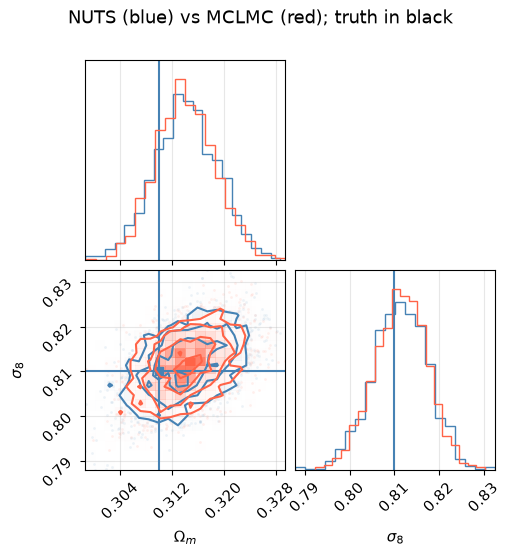

In [5]:
import corner
fig = corner.corner(nuts_samples, labels=[r'$\Omega_m$', r'$\sigma_8$'],
                    truths=[float(truth[0]), float(truth[1])], color='steelblue',
                    hist_kwargs={'density': True})
corner.corner(mclmc_samples, fig=fig, color='tomato', hist_kwargs={'density': True})
fig.suptitle('NUTS (blue) vs MCLMC (red); truth in black', y=1.02)
fig.savefig('differentiable_inference_corner.png', dpi=130, bbox_inches='tight')
plt.show()


## 5. Autodiff curvature: the Laplace approximation and information geometry

Differentiability gives more than a sampler. The **Hessian** of the negative log-posterior at the
peak is the Fisher information; its inverse is the Laplace (Gaussian) approximation of the posterior
covariance (Tegmark, Taylor & Heavens 1997) — obtained here in one line with `jax.hessian`, with no
finite differences. And the model **Jacobian** $\partial P(k_i)/\partial\theta$ tells us *which scales*
inform *which parameter* — the information geometry of the measurement.


Laplace  sigma(Om)=0.0045  sigma(s8)=0.0061
NUTS     sigma(Om)=0.0049  sigma(s8)=0.0063


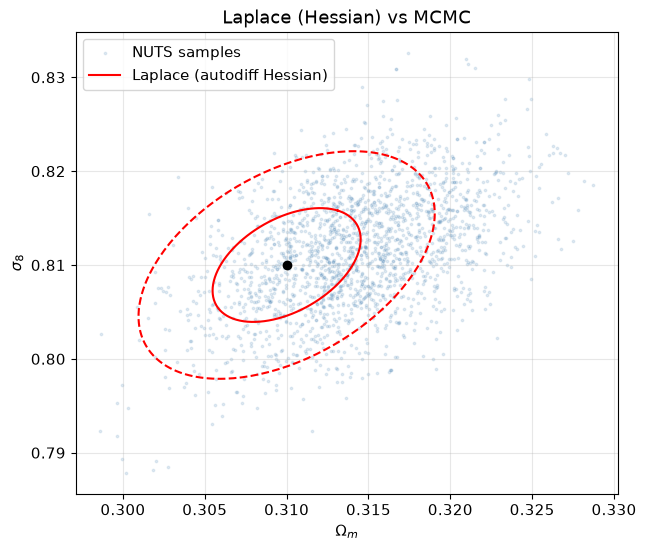

In [6]:
# Laplace approximation: covariance = inverse Hessian of -log posterior at the truth
H = jax.hessian(lambda th: -logdensity(th))(truth)
cov_laplace = np.linalg.inv(np.array(H))
print("Laplace  sigma(Om)=%.4f  sigma(s8)=%.4f" % (np.sqrt(cov_laplace[0,0]), np.sqrt(cov_laplace[1,1])))
print("NUTS     sigma(Om)=%.4f  sigma(s8)=%.4f" % (nuts_samples[:,0].std(), nuts_samples[:,1].std()))

def ell_xy(cov, mean, nsig=1):
    vals, vecs = np.linalg.eigh(cov); o = np.argsort(vals)[::-1]; vals, vecs = vals[o], vecs[:, o]
    ang = np.arctan2(vecs[1, 0], vecs[0, 0]); a, b = nsig*np.sqrt(vals)
    t = np.linspace(0, 2*np.pi, 200)
    R = np.array([[np.cos(ang), -np.sin(ang)], [np.sin(ang), np.cos(ang)]])
    xy = R @ np.array([a*np.cos(t), b*np.sin(t)])
    return mean[0]+xy[0], mean[1]+xy[1]

mu = [float(truth[0]), float(truth[1])]
plt.figure(figsize=(7, 6))
plt.scatter(nuts_samples[:, 0], nuts_samples[:, 1], s=3, alpha=0.15, color='steelblue', label='NUTS samples')
for ns_ in (1, 2):
    ex, ey = ell_xy(cov_laplace, mu, ns_)
    plt.plot(ex, ey, 'r', ls='-' if ns_ == 1 else '--', label='Laplace (autodiff Hessian)' if ns_ == 1 else None)
plt.scatter(*mu, color='k', zorder=5)
plt.xlabel(r'$\Omega_m$'); plt.ylabel(r'$\sigma_8$')
plt.title('Laplace (Hessian) vs MCMC'); plt.legend()
plt.savefig('inference_laplace_vs_mcmc.png', dpi=130); plt.show()


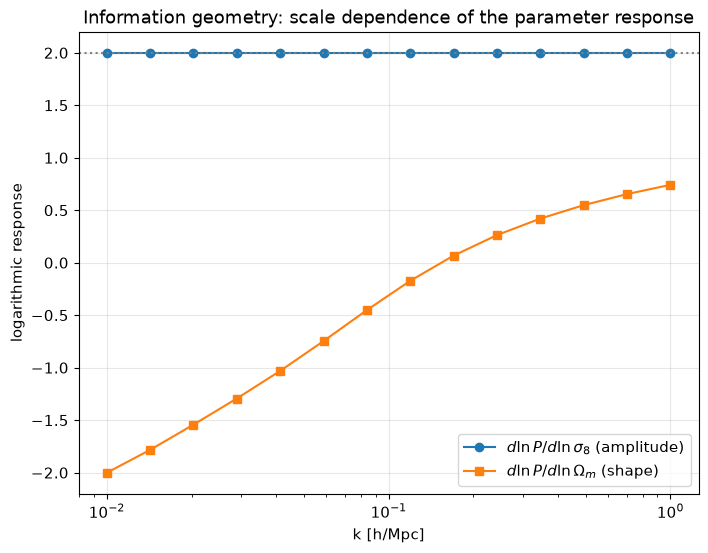

In [7]:
# Which scales constrain which parameter: the model Jacobian by autodiff
Jm = np.array(jax.jacfwd(lambda th: model_pk(kdata, th))(truth))   # (n_k, 2)
m0 = np.array(model_pk(kdata, truth))
dlnP_dlnOm = float(truth[0]) * Jm[:, 0] / m0
dlnP_dlns8 = float(truth[1]) * Jm[:, 1] / m0

plt.figure()
plt.semilogx(np.array(kdata), dlnP_dlns8, 'o-', label=r'$d\ln P/d\ln\sigma_8$ (amplitude)')
plt.semilogx(np.array(kdata), dlnP_dlnOm, 's-', label=r'$d\ln P/d\ln\Omega_m$ (shape)')
plt.axhline(2.0, color='grey', ls=':')
plt.xlabel('k [h/Mpc]'); plt.ylabel('logarithmic response'); plt.legend()
plt.title('Information geometry: scale dependence of the parameter response')
plt.savefig('inference_information_geometry.png', dpi=130); plt.show()


## Exercises

1. **Autodiff vs finite differences.** Compare `jax.grad(logdensity)` against a central finite-difference
   gradient. How does the cost scale with the number of parameters? (This is *why* gradient samplers win
   in high dimensions — the thesis regime.)
2. **Noise level.** Halve `frac_err` and rerun. Verify the posterior shrinks and stays unbiased.
3. **Add a parameter.** Free the spectral index $n_s$ as a third parameter and watch the degeneracies in
   the corner plot.
4. **Sampler diagnostics.** Compute the effective sample size per gradient evaluation for NUTS and MCLMC.
   Which is more efficient here, and would you expect the ranking to change at higher dimension
   (Robnik et al. 2023)?
5. **Toward field level.** Replace the 2-parameter model with a 1-D Gaussian-field amplitude inference
   ($N\gg2$ modes) and confirm MCLMC's relative advantage grows — the motivation for differentiable
   field-level inference in the thesis.


## Summary

- A differentiable forward model + `jax.grad` gives the log-posterior gradient automatically.
- Hamiltonian (NUTS) and micro-canonical (MCLMC) samplers both recover $(\Omega_m,\sigma_8)$.
- The autodiff **Hessian** gives the Laplace covariance (Fisher) for free, matching the MCMC; the model
  Jacobian reveals which scales constrain which parameter.
- Gradient-based samplers are what make *high-dimensional, field-level* inference tractable — the core
  methodological bet of the thesis (Jasche & Wandelt 2013; Robnik et al. 2023).

**End of Module 3.** Together N07–N13 walk from the linear power spectrum, through the multi-wavelength
observables (galaxies, lensing, SZ, X-ray), to a joint, differentiable inference of cosmological and
astrophysical parameters — the pipeline of the thesis.
